In [45]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm
import numpy as np


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import pandas as pd

results_path = "../experiments/predictive_test_results_coef0.csv"
results_df = pd.read_csv(results_path)


In [47]:
lengths = results_df.sequence_length.unique()
lengths
results_df

,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,0.019609,18.139425,18.159034,0.004714,8189.304199,8189.308914,5000
1,theta_sweeps,5,0.2625,0.070402,136.151596,136.221998,8.753879,59487.351562,59496.105441,5000
2,theta_sweeps,5,0.4250,0.008011,18.087065,18.095075,0.129084,8893.277344,8893.406428,5000
3,theta_sweeps,5,0.5875,0.022535,10.158853,10.181388,1.455129,4583.395996,4584.851125,5000
4,theta_sweeps,5,0.7500,0.007133,0.958271,0.965403,0.027414,457.014099,457.041513,5000
...,...,...,...,...,...,...,...,...,...,...
220,theta_sweeps,400,3.3500,0.043413,22.223320,22.266733,0.209325,65887.265625,65887.474950,5000
221,theta_sweeps,400,3.5125,0.063600,1.770913,1.834513,0.191548,6005.620605,6005.812154,5000
222,theta_sweeps,400,3.6750,0.061777,8.179348,8.241125,0.737118,24320.015625,24320.752743,5000
223,theta_sweeps,400,3.8375,0.031928,68.906364,68.938293,47.999437,273028.843750,273076.843187,5000


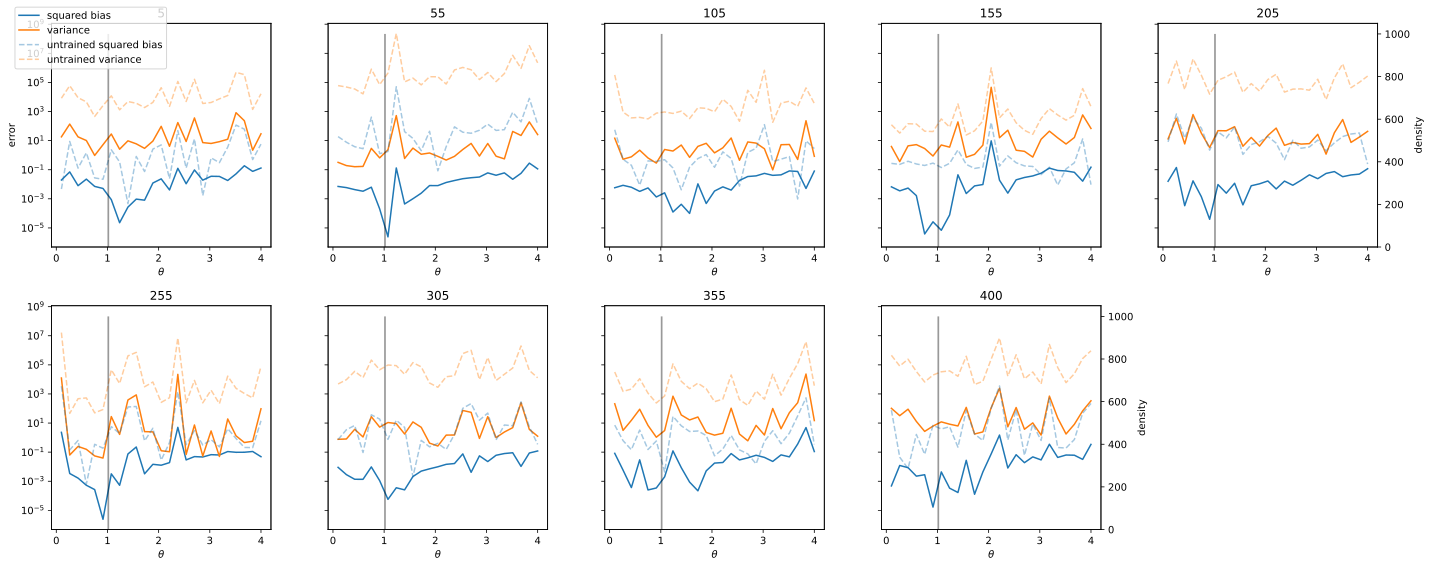

In [48]:
cfg = load_full_config()
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
data = torch.load(data_path, weights_only=False)
training_thetas = data['theta_values'].numpy()

nrows = 2
ncols = int(np.ceil(len(lengths) / nrows))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 8), sharey=True)
axs = np.atleast_1d(axs).ravel()

legend_handles, legend_labels = None, None

for i, length in enumerate(lengths):
    ax = axs[i]
    ax.set_title(f"{length}")
    df = results_df[results_df.sequence_length == length]
    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()
    ax.plot(theta, bias, "C0", label="squared bias")
    ax.semilogy(theta, variance, "C1", label="variance")
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel(r"$\theta$")
    if i == 0:
        ax.set_ylabel("error")
    axt = ax.twinx()
    axt.hist(training_thetas, 30, color="k", alpha=0.4)
    if i % ncols == ncols - 1 or i == len(lengths) - 1:
        axt.set_ylabel("density")
    else:
        axt.set_yticks([])

for j in range(len(lengths), len(axs)):
    axs[j].set_visible(False)

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout(rect=[0, 0, 1, 1])


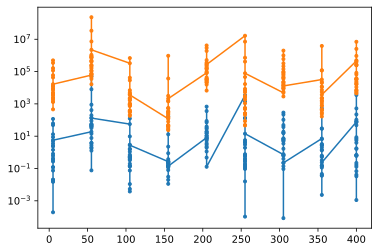

In [49]:
df = results_df[results_df.theta == results_df.theta.unique()[9]]
df = results_df #[results_df.theta == results_df.theta.unique()[9]]
bias = df.trained_squared_bias
variance = df.trained_variance
ut_bias = df.untrained_squared_bias
ut_variance = df.untrained_variance
lengths = df.sequence_length.to_numpy()

fig,ax = plt.subplots(figsize=(6,4))
ax.plot(lengths,  np.abs(bias - ut_bias), "C0.-",label="squared bias")
ax.semilogy(lengths, np.abs(variance - ut_variance), "C1.-",label="variance")

#ax.plot(lengths, ut_bias, "C0+--",label="untrained squared bias")
#ax.semilogy(lengths, ut_variance, "C1+--",label="untrained variance")

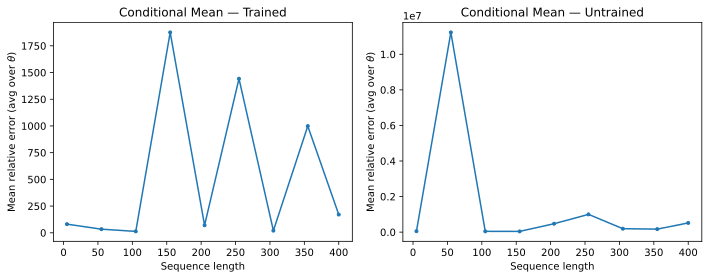

In [50]:
# Mean prediction: error averaged over all thetas per sequence length
mean_by_len = results_df.groupby("sequence_length")[
    ["trained_relative_error", "untrained_relative_error"]
].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(mean_by_len.sequence_length, mean_by_len.trained_relative_error, "C0.-")
ax1.set_xlabel("Sequence length")
ax1.set_ylabel("Mean relative error (avg over $\\theta$)")
ax1.set_title("Conditional Mean — Trained")

ax2.plot(mean_by_len.sequence_length, mean_by_len.untrained_relative_error, "C0.-")
ax2.set_xlabel("Sequence length")
ax2.set_ylabel("Mean relative error (avg over $\\theta$)")
ax2.set_title("Conditional Mean — Untrained")

plt.tight_layout()


In [51]:
# Load variance prediction results (coefficient 1)
variance_results_path = "../experiments/predictive_test_results_coef1.csv"
variance_results_df = pd.read_csv(variance_results_path)

print(f"Variance prediction results shape: {variance_results_df.shape}")
variance_results_df.head()

Variance prediction results shape: (225, 10)


,sweep_name,sequence_length,theta,trained_squared_bias,trained_variance,trained_relative_error,untrained_squared_bias,untrained_variance,untrained_relative_error,num_replicates
0,theta_sweeps,5,0.1000,324.999908,0.147106,325.147014,17081.687494,225.412781,17307.100274,5000
1,theta_sweeps,5,0.2625,40.356285,0.046620,40.402905,2482.049854,91.699844,2573.749698,5000
2,theta_sweeps,5,0.4250,13.055228,0.025375,13.080603,958.735794,56.610638,1015.346432,5000
3,theta_sweeps,5,0.5875,5.691269,0.017612,5.708880,517.722369,40.955647,558.678016,5000
4,theta_sweeps,5,0.7500,2.867125,0.012175,2.879301,326.621400,31.080896,357.702297,5000


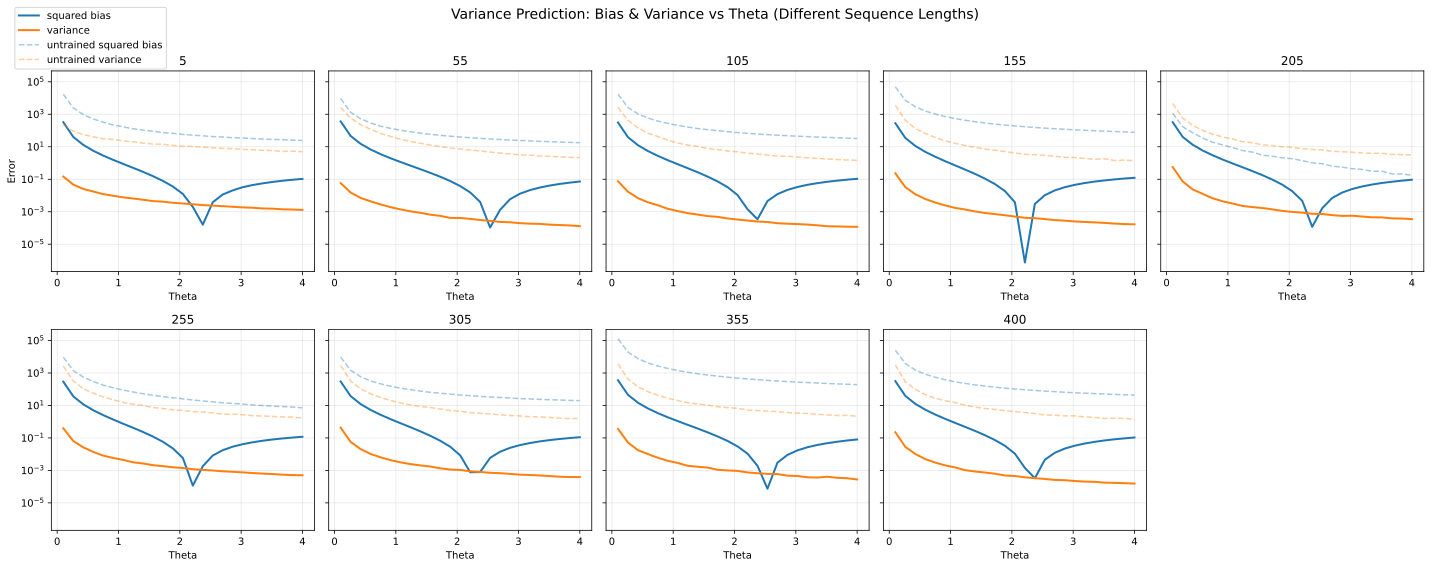

In [52]:
# Plot bias and variance vs theta for different sequence lengths (Variance Prediction)
lengths_var = variance_results_df.sequence_length.unique()

nrows = 2
ncols = int(np.ceil(len(lengths_var) / nrows))
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4 * ncols, 8), sharey=True)
axs = np.atleast_1d(axs).ravel()
fig.suptitle("Variance Prediction: Bias & Variance vs Theta (Different Sequence Lengths)", fontsize=14)

legend_handles, legend_labels = None, None

for i, length in enumerate(lengths_var):
    ax = axs[i]
    ax.set_title(f"{length}")
    df = variance_results_df[variance_results_df.sequence_length == length]

    bias = df.trained_squared_bias
    variance = df.trained_variance
    ut_bias = df.untrained_squared_bias
    ut_variance = df.untrained_variance
    theta = df.theta.to_numpy()

    ax.plot(theta, bias, "C0", label="squared bias", linewidth=2)
    ax.semilogy(theta, variance, "C1", label="variance", linewidth=2)
    ax.plot(theta, ut_bias, "C0--", label="untrained squared bias", alpha=0.4)
    ax.plot(theta, ut_variance, "C1--", label="untrained variance", alpha=0.4)

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_xlabel("Theta")
    if i == 0:
        ax.set_ylabel("Error")
    ax.grid(True, alpha=0.3)

for j in range(len(lengths_var), len(axs)):
    axs[j].set_visible(False)

if legend_handles is not None:
    fig.legend(legend_handles, legend_labels, loc="upper left", bbox_to_anchor=(0.01, 0.99))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


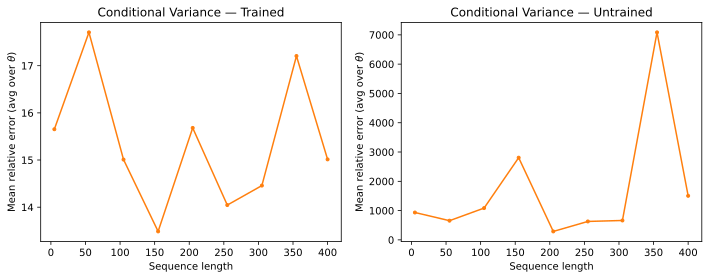

In [53]:
# Variance prediction: error averaged over all thetas per sequence length
var_by_len = variance_results_df.groupby("sequence_length")[
    ["trained_relative_error", "untrained_relative_error"]
].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(var_by_len.sequence_length, var_by_len.trained_relative_error, "C1.-")
ax1.set_xlabel("Sequence length")
ax1.set_ylabel("Mean relative error (avg over $\\theta$)")
ax1.set_title("Conditional Variance — Trained")

ax2.plot(var_by_len.sequence_length, var_by_len.untrained_relative_error, "C1.-")
ax2.set_xlabel("Sequence length")
ax2.set_ylabel("Mean relative error (avg over $\\theta$)")
ax2.set_title("Conditional Variance — Untrained")

plt.tight_layout()
